<a href="https://colab.research.google.com/github/Chetan-Patil-52/5th-Sem/blob/main/Expt_1_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install nltk
!pip install spacy
!python -m spacy download en_core_web_sm
!pip install matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 60.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [1]:
import nltk
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.probability import FreqDist
from nltk.tokenize import word_tokenize
import spacy
from spacy.lang.en.stop_words import STOP_WORDS


In [ ]:
text = """
Natural language processing (NLP) refers to the branch of computer science concerned with giving computers the ability
to understand text and spoken words in much the same way human beings can. Together, these technologies enable
computers to process human language in the form of text or voice data and to ‘understand’ its full meaning, complete
with the speaker or writer’s intent and sentiment. NLP drives computer programs that translate text from one language
to another, respond to spoken commands, and summarize large volumes of text rapidly—even in real time.
"""


In [4]:
import spacy

# Load SpaCy's English model
nlp = spacy.load('en_core_web_sm')

# Sample text
text = """
Natural language processing (NLP) refers to the branch of computer science concerned with giving computers the ability
to understand text and spoken words in much the same way human beings can. Together, these technologies enable
computers to process human language in the form of text or voice data and to ‘understand’ its full meaning, complete
with the speaker or writer’s intent and sentiment. NLP drives computer programs that translate text from one language
to another, respond to spoken commands, and summarize large volumes of text rapidly—even in real time.
"""

# Process the text through SpaCy
doc = nlp(text)

# Get words from the SpaCy doc object
words_spacy = [token.text for token in doc]

# Displaying words
print(words_spacy)


['\n', 'Natural', 'language', 'processing', '(', 'NLP', ')', 'refers', 'to', 'the', 'branch', 'of', 'computer', 'science', 'concerned', 'with', 'giving', 'computers', 'the', 'ability', '\n', 'to', 'understand', 'text', 'and', 'spoken', 'words', 'in', 'much', 'the', 'same', 'way', 'human', 'beings', 'can', '.', 'Together', ',', 'these', 'technologies', 'enable', '\n', 'computers', 'to', 'process', 'human', 'language', 'in', 'the', 'form', 'of', 'text', 'or', 'voice', 'data', 'and', 'to', '‘', 'understand', '’', 'its', 'full', 'meaning', ',', 'complete', '\n', 'with', 'the', 'speaker', 'or', 'writer', '’s', 'intent', 'and', 'sentiment', '.', 'NLP', 'drives', 'computer', 'programs', 'that', 'translate', 'text', 'from', 'one', 'language', '\n', 'to', 'another', ',', 'respond', 'to', 'spoken', 'commands', ',', 'and', 'summarize', 'large', 'volumes', 'of', 'text', 'rapidly', '—', 'even', 'in', 'real', 'time', '.', '\n']


Using library (Counter): [('text', 4), ('language', 3), ('nlp', 2), ('computer', 2), ('computers', 2), ('understand', 2), ('spoken', 2), ('human', 2), ('natural', 1), ('processing', 1)]
Without using library (manual): [('text', 4), ('language', 3), ('nlp', 2), ('computer', 2), ('computers', 2), ('understand', 2), ('spoken', 2), ('human', 2), ('natural', 1), ('processing', 1)]


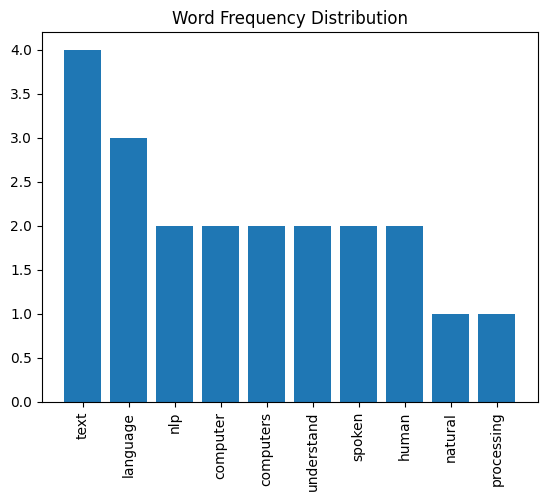

In [5]:
import spacy
from collections import Counter
import matplotlib.pyplot as plt
from spacy.lang.en.stop_words import STOP_WORDS

# Load SpaCy's English model
nlp = spacy.load('en_core_web_sm')

# Sample text
text = """
Natural language processing (NLP) refers to the branch of computer science concerned with giving computers the ability
to understand text and spoken words in much the same way human beings can. Together, these technologies enable
computers to process human language in the form of text or voice data and to ‘understand’ its full meaning, complete
with the speaker or writer’s intent and sentiment. NLP drives computer programs that translate text from one language
to another, respond to spoken commands, and summarize large volumes of text rapidly—even in real time.
"""

# Process the text through SpaCy
doc = nlp(text)

# Get filtered words from the SpaCy doc object
words_spacy = [token.text.lower() for token in doc if token.text.lower() not in STOP_WORDS and not token.is_punct and not token.is_space]

# 1. Using a library (Counter)
word_count_lib = Counter(words_spacy)
print("Using library (Counter):", word_count_lib.most_common(10))

# 2. Without using a library (manual count)
word_count_manual = {}
for word in words_spacy:
    word_count_manual[word] = word_count_manual.get(word, 0) + 1
sorted_word_count_manual = sorted(word_count_manual.items(), key=lambda x: x[1], reverse=True)
print("Without using library (manual):", sorted_word_count_manual[:10])

# Plotting frequency distribution using Matplotlib
top_words = [word for word, _ in sorted_word_count_manual[:10]]
top_freqs = [freq for _, freq in sorted_word_count_manual[:10]]
plt.bar(top_words, top_freqs)
plt.xticks(rotation=90)
plt.title("Word Frequency Distribution")
plt.show()


[('\n', 6), ('to', 6), ('the', 5), ('text', 4), ('and', 4), (',', 4), ('language', 3), ('of', 3), ('in', 3), ('.', 3)]


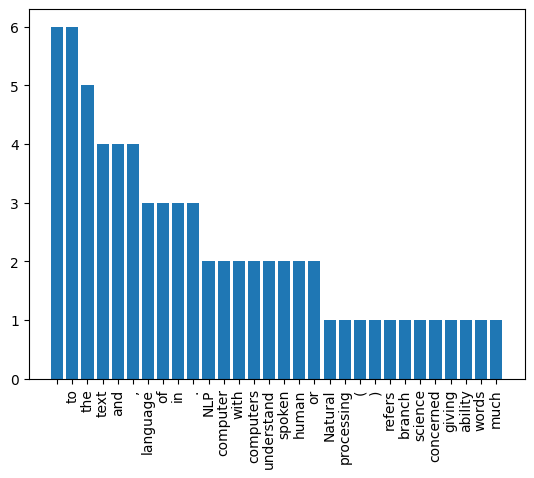

In [ ]:
# Count word frequencies manually
word_count = {}
for word in words_spacy:
    word_count[word] = word_count.get(word, 0) + 1

# Displaying the frequency of the top 10 words
sorted_word_count = sorted(word_count.items(), key=lambda x: x[1], reverse=True)
print(sorted_word_count[:10])

# Plotting frequency distribution using Matplotlib
word_list = [word for word, _ in sorted_word_count[:30]]  # Top 30 words
frequency = [count for _, count in sorted_word_count[:30]]
plt.bar(word_list, frequency)
plt.xticks(rotation=90)
plt.show()

In [7]:
# Removing stopwords from text using SpaCy
filtered_words_spacy = [word.text for word in doc if word.text.lower() not in STOP_WORDS and not word.is_punct and not word.is_space]
filtered_text_spacy = ' '.join(filtered_words_spacy)
print(filtered_text_spacy)


Natural language processing NLP refers branch computer science concerned giving computers ability understand text spoken words way human beings technologies enable computers process human language form text voice data understand meaning complete speaker writer intent sentiment NLP drives computer programs translate text language respond spoken commands summarize large volumes text rapidly real time


In [ ]:
# Manually defining stop words
stop_words_manual = {"the", "a", "to", "and", "of", "in", "on", "with", "for", "by", "an", "it", "as", "at", "this"}

# Removing stopwords manually
filtered_words_manual = [word for word in words_spacy if word.lower() not in stop_words_manual]
filtered_text_manual = ' '.join(filtered_words_manual)
print(filtered_text_manual)



 Natural language processing ( NLP ) refers branch computer science concerned giving computers ability 
 understand text spoken words much same way human beings can . Together , these technologies enable 
 computers process human language form text or voice data ‘ understand ’ its full meaning , complete 
 speaker or writer ’s intent sentiment . NLP drives computer programs that translate text from one language 
 another , respond spoken commands , summarize large volumes text rapidly — even real time . 



In [12]:
# Using SpaCy's built-in stop words
filtered_words_spacy = [word.text for word in doc if word.text.lower() not in STOP_WORDS and not word.is_punct and not word.is_space]
filtered_text_spacy = ' '.join(filtered_words_spacy)
print("Text without stop words (using SpaCy):")
print(filtered_text_spacy)

print('\n')

# Manually removing stop words
stop_words_manual = {"the", "a", "to", "and", "of", "in", "on", "with", "for", "by", "an", "it", "as", "at", "this"}
filtered_words_manual = [word for word in words_spacy if word.lower() not in stop_words_manual]
filtered_text_manual = ' '.join(filtered_words_manual)
print("Text without stop words (manually):")
print(filtered_text_manual)


Text without stop words (using SpaCy):
Natural language processing NLP refers branch computer science concerned giving computers ability understand text spoken words way human beings technologies enable computers process human language form text voice data understand meaning complete speaker writer intent sentiment NLP drives computer programs translate text language respond spoken commands summarize large volumes text rapidly real time


Text without stop words (manually):
natural language processing nlp refers branch computer science concerned giving computers ability understand text spoken words way human beings technologies enable computers process human language form text voice data understand meaning complete speaker writer intent sentiment nlp drives computer programs translate text language respond spoken commands summarize large volumes text rapidly real time


In [13]:
# Using SpaCy to identify stop words
stop_words_in_text_spacy = [word.text for word in doc if word.text.lower() in STOP_WORDS]
print("Stop words in the paragraph (using SpaCy):")
print(set(stop_words_in_text_spacy))

# Manually identifying stop words
stop_words_manual = {"the", "a", "to", "and", "of", "in", "on", "with", "for", "by", "an", "it", "as", "at", "this"}
stop_words_in_text_manual = [word.text for word in doc if word.text.lower() in stop_words_manual]
print("\nStop words in the paragraph (manually):")
print(set(stop_words_in_text_manual))

Stop words in the paragraph (using SpaCy):
{'and', 'to', 'that', 'full', 'Together', 'another', 'these', 'much', 'with', 'from', 'even', 'can', 'the', 'or', 'same', 'of', 'one', 'its', '’s', 'in'}

Stop words in the paragraph (manually):
{'and', 'to', 'in', 'the', 'with', 'of'}


In [14]:
# Using Spacy library
stop_words_in_text_spacy = [word.text for word in doc if word.text.lower() in STOP_WORDS]
print("Stop words in the paragraph (using SpaCy):")
print(set(stop_words_in_text_spacy))


Stop words in the paragraph (using SpaCy):
{'and', 'to', 'that', 'full', 'Together', 'another', 'these', 'much', 'with', 'from', 'even', 'can', 'the', 'or', 'same', 'of', 'one', 'its', '’s', 'in'}


In [15]:
stop_words_manual = {"the", "a", "to", "and", "of", "in", "on", "with", "for", "by", "an", "it", "as", "at", "this"}
stop_words_in_text_manual = [word.text for word in doc if word.text.lower() in stop_words_manual]
print("\nStop words in the paragraph (manually):")
print(set(stop_words_in_text_manual))



Stop words in the paragraph (manually):
{'and', 'to', 'in', 'the', 'with', 'of'}


In [16]:
from spacy.lang.en.stop_words import STOP_WORDS

# Customize SpaCy's stop word list
STOP_WORDS.add("custom_word")  # Adding a word
STOP_WORDS.remove("you")       # Removing a word
